In [53]:
import pandas as pd
from pathlib import Path
import json

In [54]:
SAMPLE_DIR = Path("samples/v3_1000/res_20250627_n100")

responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
responses_df['references'] = responses_df['references'].apply(json.loads)
responses_df['organic_results'] = responses_df['organic_results'].apply(json.loads)
classified_urls_df = pd.read_csv(SAMPLE_DIR / "__classified_urls.csv")
unclassified_urls_df = pd.read_csv(SAMPLE_DIR / "__unclassified_urls.csv")

## By unique document

In [55]:
# Define classified sets
ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

# Define citation sets
cited_urls = set()
cited_from_organic_urls = set()

for _, row in responses_df.iterrows():
    try:
        refs = set(row["references"])
        organic = set(row["organic_results"])
        cited_urls.update(refs)
        cited_from_organic_urls.update(refs & organic)
    except Exception:
        continue

# Totals
ai_total = len(ai_urls)
human_total = len(human_urls)

print('ai total', ai_total)
print('human total', human_total)

# AI stats
ai_cited = len(cited_urls & ai_urls)
ai_cited_from_organic = len(cited_from_organic_urls & ai_urls)
ai_cited_outside_organic = ai_cited - ai_cited_from_organic

print('ai_cited', ai_cited)
print('ai_cited_from_organic', ai_cited_from_organic)
print('ai_cited_outside_organic', ai_cited_outside_organic)

# Human stats
human_cited = len(cited_urls & human_urls)
human_cited_from_organic = len(cited_from_organic_urls & human_urls)
human_cited_outside_organic = human_cited - human_cited_from_organic

print('human_cited', human_cited)
print('human_cited_from_organic', human_cited_from_organic)
print('human_cited_outside_organic', human_cited_outside_organic)

print()

# Probabilities (safeguarded)
p_ai_cited = ai_cited / ai_total if ai_total else 0
p_ai_cited_from_organic = ai_cited_from_organic / ai_total if ai_total else 0
p_ai_cited_outside_organic = ai_cited_outside_organic / ai_total if ai_total else 0

p_human_cited = human_cited / human_total if human_total else 0
p_human_cited_from_organic = human_cited_from_organic / human_total if human_total else 0
p_human_cited_outside_organic = human_cited_outside_organic / human_total if human_total else 0

# Output
print("P(cited | AI):", f"{p_ai_cited * 100:.2f}%")
print("P(cited-from-organic | AI):", f"{p_ai_cited_from_organic * 100:.2f}%")
print("P(cited-out-of-organic | AI):", f"{p_ai_cited_outside_organic * 100:.2f}%")
print()
print("P(cited | Human):", f"{p_human_cited * 100:.2f}%")
print("P(cited-from-organic | Human):", f"{p_human_cited_from_organic * 100:.2f}%")
print("P(cited-out-of-organic | Human):", f"{p_human_cited_outside_organic * 100:.2f}%")


ai total 3128
human total 20863
ai_cited 861
ai_cited_from_organic 248
ai_cited_outside_organic 613
human_cited 3120
human_cited_from_organic 1741
human_cited_outside_organic 1379

P(cited | AI): 27.53%
P(cited-from-organic | AI): 7.93%
P(cited-out-of-organic | AI): 19.60%

P(cited | Human): 14.95%
P(cited-from-organic | Human): 8.34%
P(cited-out-of-organic | Human): 6.61%


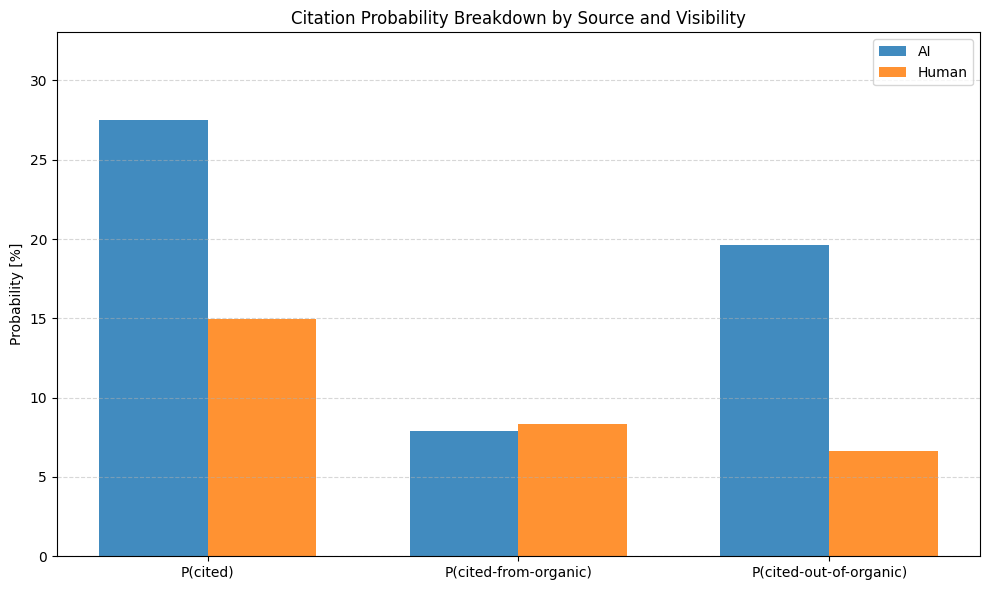

In [56]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['P(cited)', 'P(cited-from-organic)', 'P(cited-out-of-organic)']
ai_values = [
    p_ai_cited * 100,
    p_ai_cited_from_organic * 100,
    p_ai_cited_outside_organic * 100,
]
human_values = [
    p_human_cited * 100,
    p_human_cited_from_organic * 100,
    p_human_cited_outside_organic * 100,
]

x = np.arange(len(labels))  # label locations
width = 0.35  # bar width

# Plot
plt.figure(figsize=(10, 6))
plt.bar(x - width/2, ai_values, width, label='AI', alpha=0.85)
plt.bar(x + width/2, human_values, width, label='Human', alpha=0.85)

# Labels and styling
plt.ylabel('Probability [%]')
plt.title('Citation Probability Breakdown by Source and Visibility')
plt.xticks(x, labels)
plt.ylim(0, max(ai_values + human_values) * 1.2)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## By Google result appearance

P(cited-from-organic | AI & in-top-k)

P(cited-from-organic | Human & in-top-k)

In [57]:
cutoffs = list(range(1, 101))
p_ai_list = []
p_human_list = []

ai_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "AI"]["url"])
human_urls = set(classified_urls_df[classified_urls_df["ai_class"] == "Human"]["url"])

for k in cutoffs:
    ai_total = ai_cited = human_total = human_cited = 0

    for _, row in responses_df.iterrows():
        try:
            refs = set(row["references"])
            organic = row["organic_results"][:k]
        except Exception:
            continue

        for url in organic:
            if url in ai_urls:
                ai_total += 1
                if url in refs:
                    ai_cited += 1
            elif url in human_urls:
                human_total += 1
                if url in refs:
                    human_cited += 1

    p_ai = ai_cited / ai_total if ai_total else 0
    p_human = human_cited / human_total if human_total else 0

    # print(ai_total)

    p_ai_list.append(p_ai * 100)
    p_human_list.append(p_human * 100)

# p_ai_list.reverse()
# p_human_list.reverse()

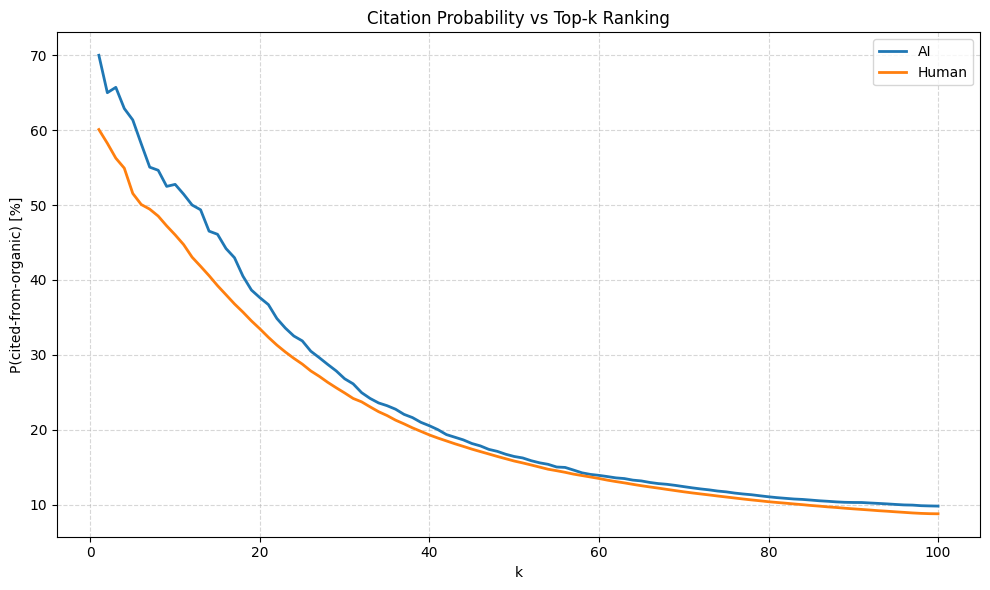


Selected citation probabilities:

Top-  1: AI 70.00% vs Human 60.08% ( 9.92)
Top-  5: AI 61.36% vs Human 51.54% ( 9.82)
Top- 10: AI 52.76% vs Human 46.01% ( 6.74)
Top- 20: AI 37.63% vs Human 33.46% ( 4.16)
Top- 30: AI 26.79% vs Human 24.90% ( 1.90)
Top- 50: AI 16.42% vs Human 15.81% ( 0.61)
Top-100: AI  9.79% vs Human  8.76% ( 1.03)


In [58]:
plt.figure(figsize=(10, 6))
plt.plot(cutoffs, p_ai_list, '-', label="AI", linewidth=2)
plt.plot(cutoffs, p_human_list, '-', label="Human", linewidth=2)
plt.xlabel("k")
plt.ylabel("P(cited-from-organic) [%]")
plt.title("Citation Probability vs Top-k Ranking")
# plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# # Add vertical difference lines
# for x, ai, human in zip(cutoffs, p_ai_list, p_human_list):
#     color = 'tab:blue' if ai > human else 'tab:orange'
#     plt.vlines(x, ymin=min(ai, human), ymax=max(ai, human),
#                colors='black', linestyles='-', lw=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

# Display selected cutoff probabilities
key_cutoffs = [1, 5, 10, 20, 30, 50, 100]
print("\nSelected citation probabilities:\n")
for k in key_cutoffs:
    ai_val = p_ai_list[k - 1]
    human_val = p_human_list[k - 1]
    print(f"Top-{k:3d}: AI {ai_val:5.2f}% vs Human {human_val:5.2f}% ({abs(ai_val - human_val):5.2f})")


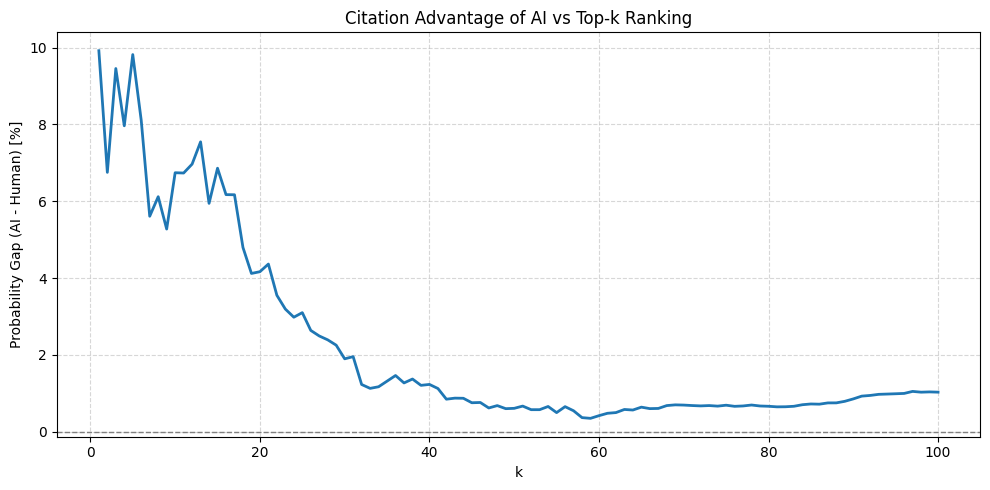

In [59]:
# Calculate the gap (AI - Human) at each k
gap_list = [ai - human for ai, human in zip(p_ai_list, p_human_list)]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(cutoffs, gap_list, '-', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("k")
plt.ylabel("Probability Gap (AI - Human) [%]")
plt.title("Citation Advantage of AI vs Top-k Ranking")
# plt.gca().invert_xaxis()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
